# **EDA of WhatsApp Integrity Data**

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [18]:
df = pd.read_csv('data/data.csv')
df.drop(columns=["spam_report_count"], inplace=True)
df.head(3)

,sender_phone,is_business,about_text,is_verified_biz,body,label
0,9.230000e+11,1,Lucky Draw Verification,0,"You won Rs.50,000! Claim here http://reward.xyz",phishing
1,9.230000e+11,1,Bank Helpdesk,0,Your account is locked. Verify now at http://s...,phishing
2,9.230000e+11,1,Busy,1,"Hey, check the lab assignment details on the p...",safe


- **categorical**:is_business, is_verified_biz
  
  
- **mixed**:sender_phone, about_text, body

In [19]:
df.shape

(1890, 6)

In [20]:
df.isnull().sum()

sender_phone       0
is_business        0
about_text         0
is_verified_biz    0
body               0
label              0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.shape

(1890, 6)

## Univariate Analysis

In [32]:
print ("Business accounts: ", df['is_business'].sum(),"and Non-Business accounts: ", len(df)-df['is_business'].sum())
print ("Verified Business accounts: ", df['is_verified_biz'].sum(),"and Non-Verified Business accounts: ", len(df)-df['is_verified_biz'].sum())

Business accounts:  845 and Non-Business accounts:  1045
Verified Business accounts:  204 and Non-Verified Business accounts:  1686


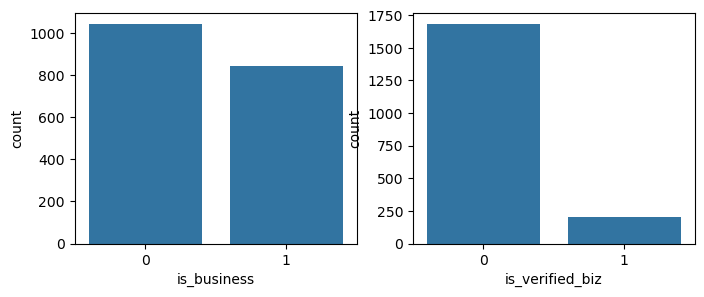

In [9]:
plt.figure(figsize=(8, 3)) 

plt.subplot(1, 2, 1)
sns.countplot(x='is_business', data=df)

plt.subplot(1, 2, 2)
sns.countplot(x='is_verified_biz', data=df)


plt.show()

## Feature Engineering

In [27]:
import re
# YE BANAO — model ke liye features
def create_features(row):
    text = row['body'].lower() if isinstance(row['body'], str) else ''
    
    has_url = 1 if re.search(r'(https?://|www\.)\S+', text) else 0
    has_shortener = 1 if any(s in text for s in ['bit.ly','tinyurl','t.co','ow.ly']) else 0
    has_urgency = 1 if any(w in text for w in ['urgent','immediately','now','final notice','suspended','disconnected','unpaid']) else 0
    has_action_words = 1 if any(w in text for w in ['pay','claim','fund','login','verify','account']) else 0
    
    return pd.Series([has_url, has_shortener, has_urgency, has_action_words])

df[['has_url','has_shortener','has_urgency','has_action_words']] = df.apply(create_features, axis=1)
df.sample(3)

,sender_phone,is_business,about_text,is_verified_biz,body,label,has_url,has_shortener,has_urgency,has_action_words
1305,8.801452e+10,0,Prize Claim Center,0,URGENT: Your bank account has been suspended. ...,phishing,1,1,1,1
1148,9.192702e+09,1,Govt Grant Office,0,"Prize notification: Rs.5,000 cash prize. Claim...",phishing,1,0,0,1
1002,8.801445e+10,1,Govt Grant Office,0,HBL Bank alert: Verify your account now at htt...,phishing,1,0,1,1


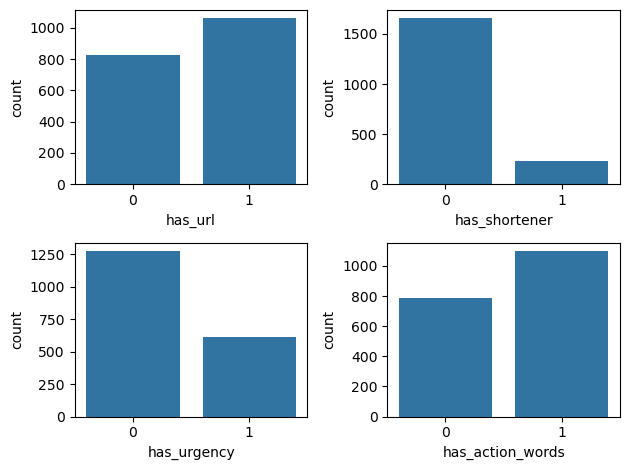

In [15]:
plt.subplot(2, 2, 1)
sns.countplot(x='has_url', data=df)
plt.subplot(2, 2, 2)
sns.countplot(x='has_shortener', data=df)
plt.subplot(2, 2, 3)
sns.countplot(x='has_urgency', data=df)
plt.subplot(2, 2, 4)
sns.countplot(x='has_action_words', data=df)
plt.tight_layout()


## Multivariate Analysis

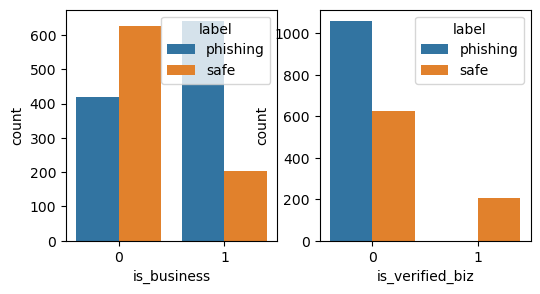

In [30]:
plt.figure(figsize=(6, 3)) 

plt.subplot(1, 2, 1)
sns.countplot(x='is_business', data=df, hue="label")

plt.subplot(1, 2, 2)
sns.countplot(x='is_verified_biz', data=df, hue="label")

plt.show()

- Spam accounts are irrespective of their business status.
- Verified accounts are 100% safe while non verified accounts are less safe.

- Numbers with more spam report count are phishing numbers